# PhishGuard — Model Training & Evaluation

Week 2 deliverable. Covers:
1. Training results summary across all four models
2. ROC curves (all models on one plot)
3. Confusion matrices
4. Precision-Recall curves and threshold analysis
5. XGBoost feature importances (top 20)
6. Error analysis — what does the best model still miss?

In [1]:
import sys
sys.path.insert(0, "..")
import warnings, logging
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

ARTIFACTS = Path("../models/artifacts")
MODEL_NAMES = ["logistic_regression", "naive_bayes", "random_forest", "xgboost"]
COLORS = ["#4C9BE8", "#F5A623", "#7ED321", "#E8644C"]

# Recreate the same 80/20 split used during training
df = pd.read_csv("../data/processed/cleaned.csv").fillna("")
y  = df["label"].values
X_df = df.drop(columns=["label", "source"], errors="ignore")
_, X_test_df, _, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42, stratify=y
)

# Load all artifacts
artifacts = {}
for name in MODEL_NAMES:
    p = ARTIFACTS / f"{name}.joblib"
    if p.exists():
        artifacts[name] = joblib.load(p)

print("Loaded models:", list(artifacts.keys()))

Loaded models: ['logistic_regression', 'naive_bayes', 'random_forest', 'xgboost']


## 1. Results Summary

All metrics evaluated on the held-out 20% test set (1,091 emails) with each model's tuned threshold.

In [2]:
rows = []
for name, art in artifacts.items():
    m = art["metrics"]
    rows.append({
        "Model":     name.replace("_", " ").title(),
        "Threshold": f"{art['threshold']:.2f}",
        "Accuracy":  f"{m['accuracy']:.4f}",
        "Precision": f"{m['precision']:.4f}",
        "Recall":    f"{m['recall']:.4f}",
        "F1":        f"{m['f1']:.4f}",
        "ROC-AUC":   f"{m['roc_auc']:.4f}",
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

              Model Threshold Accuracy Precision Recall     F1 ROC-AUC
Logistic Regression      0.89   0.9743    0.9981 0.9505 0.9737  0.9981
        Naive Bayes      0.50   0.7846    0.9586 0.5945 0.7339  0.9585
      Random Forest      0.69   0.9762    0.9924 0.9596 0.9757  0.9982
            Xgboost      0.76   0.9844    0.9962 0.9725 0.9842  0.9991


## 2. ROC Curves

ROC curves for all four models on the same axes. AUC values are annotated.

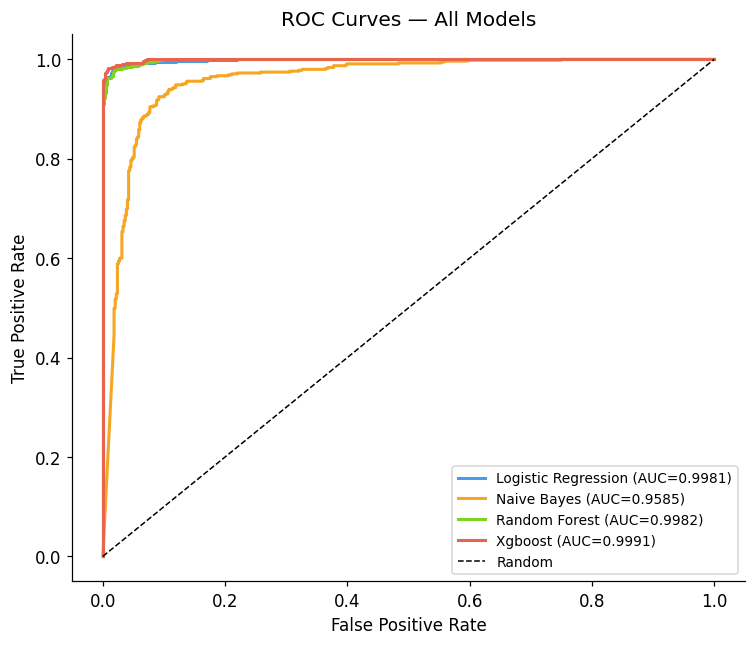

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))

for (name, art), color in zip(artifacts.items(), COLORS):
    fp_pipe = art["feature_pipeline"]
    model   = art["model"]
    X_feat  = fp_pipe.transform(X_test_df)
    y_prob  = model.predict_proba(X_feat)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    label = f"{name.replace('_', ' ').title()} (AUC={roc_auc:.4f})"
    ax.plot(fpr, tpr, color=color, linewidth=2, label=label)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Confusion Matrices

Confusion matrices at each model's tuned threshold. Goal: minimise false negatives (phishing missed = bottom-left cell).

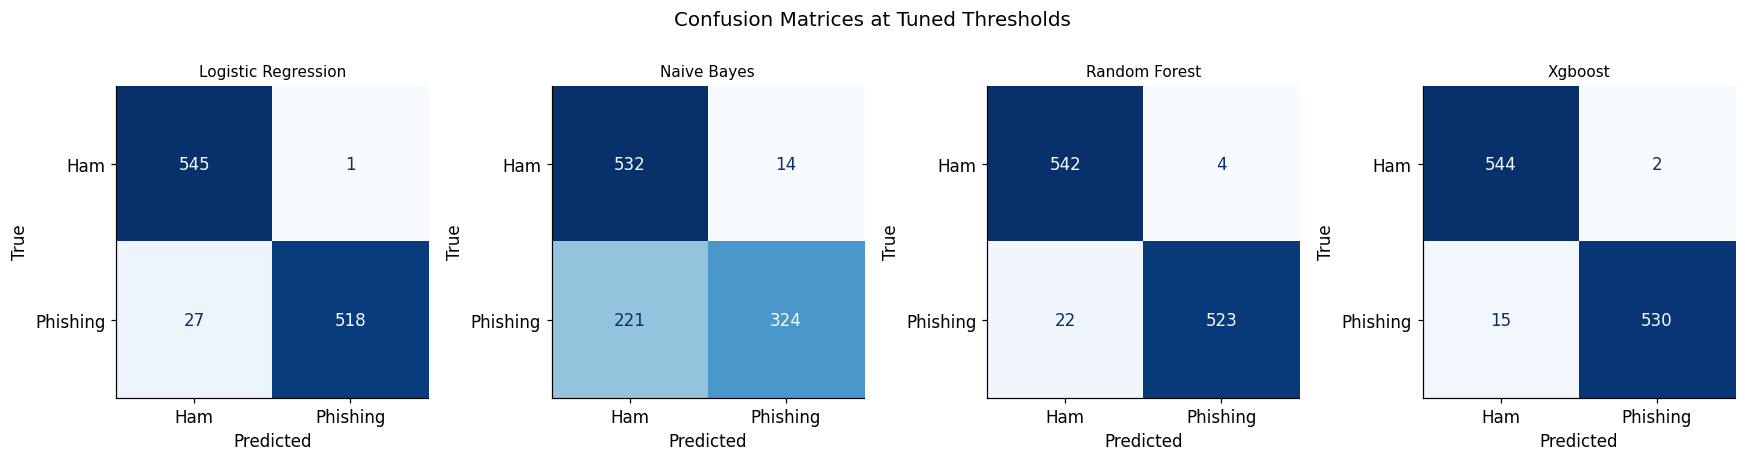

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, art), color in zip(axes, artifacts.items(), COLORS):
    fp_pipe   = art["feature_pipeline"]
    model     = art["model"]
    threshold = art["threshold"]
    X_feat    = fp_pipe.transform(X_test_df)
    y_prob    = model.predict_proba(X_feat)[:, 1]
    y_pred    = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Ham", "Phishing"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices at Tuned Thresholds", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Precision-Recall Curves & Threshold Analysis

For phishing detection, recall (catching real phishing) matters more than precision (avoiding false alarms). The shaded region shows thresholds where recall ≥ 0.95.

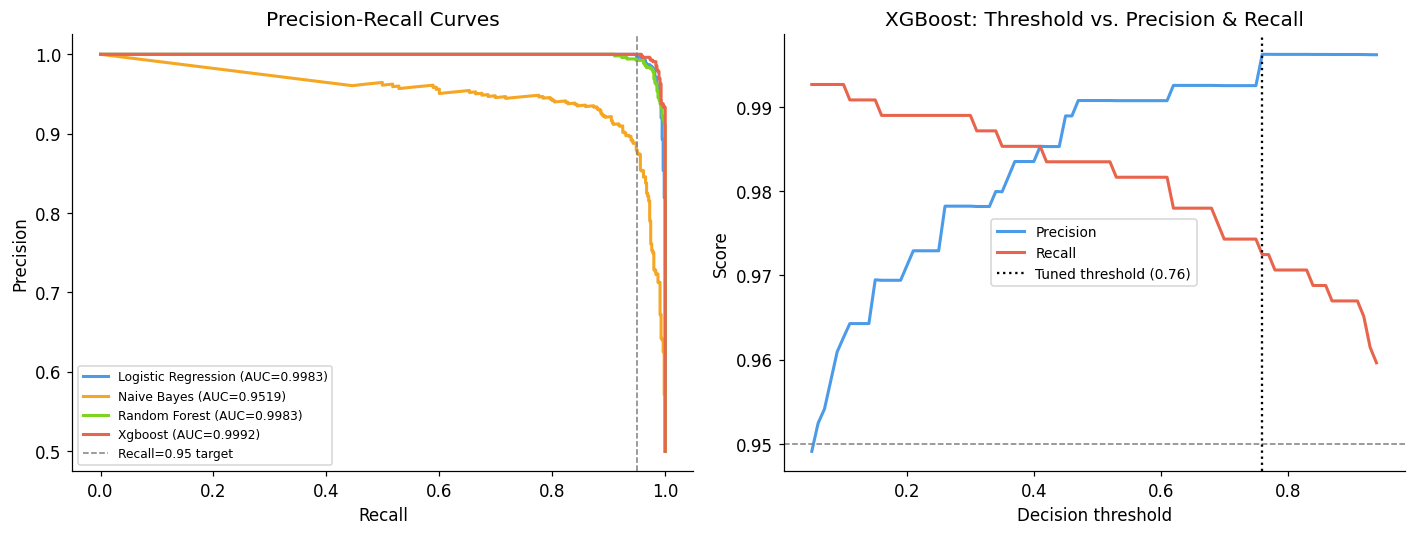

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Precision-Recall curves
for (name, art), color in zip(artifacts.items(), COLORS):
    fp_pipe = art["feature_pipeline"]
    model   = art["model"]
    X_feat  = fp_pipe.transform(X_test_df)
    y_prob  = model.predict_proba(X_feat)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec, prec)
    axes[0].plot(rec, prec, color=color, linewidth=2,
                 label=f"{name.replace('_', ' ').title()} (AUC={pr_auc:.4f})")

axes[0].axvline(0.95, color="grey", linestyle="--", linewidth=1, label="Recall=0.95 target")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curves")
axes[0].legend(fontsize=8)

# Right: Threshold vs. Precision & Recall for best model (XGBoost)
if "xgboost" in artifacts:
    art    = artifacts["xgboost"]
    X_feat = art["feature_pipeline"].transform(X_test_df)
    y_prob = art["model"].predict_proba(X_feat)[:, 1]
    thresholds = np.arange(0.05, 0.95, 0.01)
    from sklearn.metrics import precision_score, recall_score
    precisions = [precision_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
    recalls    = [recall_score(y_test,    (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
    axes[1].plot(thresholds, precisions, label="Precision", color="#4C9BE8", linewidth=2)
    axes[1].plot(thresholds, recalls,    label="Recall",    color="#E8644C", linewidth=2)
    axes[1].axhline(0.95, color="grey", linestyle="--", linewidth=1)
    axes[1].axvline(art["threshold"], color="black", linestyle=":", linewidth=1.5,
                    label=f"Tuned threshold ({art['threshold']:.2f})")
    axes[1].set_xlabel("Decision threshold")
    axes[1].set_ylabel("Score")
    axes[1].set_title("XGBoost: Threshold vs. Precision & Recall")
    axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Feature Importance — XGBoost (Top 20)

XGBoost's built-in gain-based importance across all 130 features. Highlights which signals drive the best model's decisions.

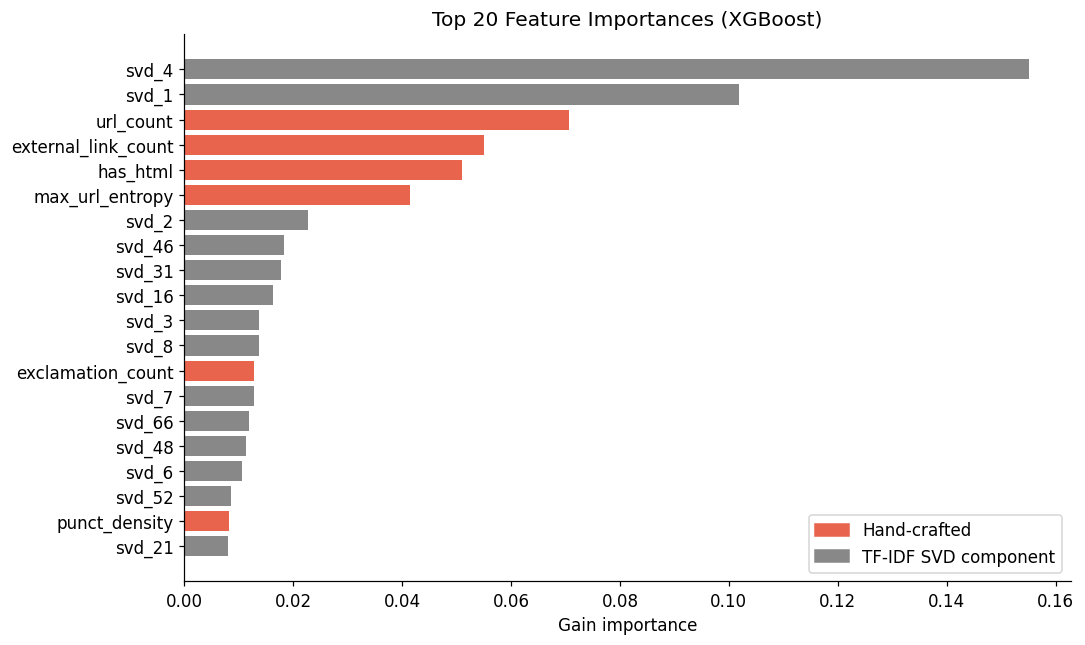

In [6]:
from src.features.pipeline import get_feature_names

if "xgboost" in artifacts:
    art      = artifacts["xgboost"]
    xgb      = art["model"]
    fp_pipe  = art["feature_pipeline"]
    f_names  = get_feature_names(fp_pipe)
    HAND_CRAFTED = f_names[:30]

    importances = xgb.feature_importances_
    idx = np.argsort(importances)[::-1][:20]

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#E8644C" if f_names[i] in HAND_CRAFTED else "#888" for i in idx]
    ax.barh(
        [f_names[i] for i in idx][::-1],
        importances[idx][::-1],
        color=colors[::-1],
    )
    ax.set_xlabel("Gain importance")
    ax.set_title("Top 20 Feature Importances (XGBoost)")

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="#E8644C", label="Hand-crafted"),
        Patch(color="#888",    label="TF-IDF SVD component"),
    ], loc="lower right")
    plt.tight_layout()
    plt.show()

## 6. Error Analysis — What Does the Best Model Still Miss?

Inspect the false negatives: phishing emails the best model failed to flag. Understanding their properties informs Week 3 feature and threshold work.

In [7]:
if "xgboost" in artifacts:
    art       = artifacts["xgboost"]
    fp_pipe   = art["feature_pipeline"]
    model     = art["model"]
    threshold = art["threshold"]

    X_feat = fp_pipe.transform(X_test_df)
    y_prob = model.predict_proba(X_feat)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    fn_idx = np.where((y_test == 1) & (y_pred == 0))[0]
    tp_idx = np.where((y_test == 1) & (y_pred == 1))[0]
    fp_idx = np.where((y_test == 0) & (y_pred == 1))[0]

    print(f"Test set breakdown:")
    print(f"  True positives  (phishing caught) : {len(tp_idx)}")
    print(f"  False negatives (phishing missed) : {len(fn_idx)}")
    print(f"  False positives (ham flagged)     : {len(fp_idx)}")
    print(f"  True negatives  (ham cleared)     : {(y_test==0).sum() - len(fp_idx)}")
    print()

    fn_df = X_test_df.iloc[fn_idx].copy()
    fn_df["confidence"] = y_prob[fn_idx]
    fn_df = fn_df.sort_values("confidence")

    print("False negatives — 5 lowest-confidence examples:")
    print("─" * 60)
    for _, row in fn_df.head(5).iterrows():
        subj = row["subject"][:60] if row["subject"] else "(no subject)"
        body_preview = row["body"][:80].replace("\n", " ")
        print(f"  Confidence : {row['confidence']:.3f}")
        print(f"  Subject    : {subj}")
        print(f"  Body       : {body_preview}...")
        print()

Test set breakdown:
  True positives  (phishing caught) : 530
  False negatives (phishing missed) : 15
  False positives (ham flagged)     : 2
  True negatives  (ham cleared)     : 544

False negatives — 5 lowest-confidence examples:
────────────────────────────────────────────────────────────
  Confidence : 0.020
  Subject    : Call me                    37661
  Body       : Hello I am your hot lil horny toy.     I am the one you dream About,     I am a ...

  Confidence : 0.022
  Subject    : Fw: Mould Purchase Order - order#84014
  Body       : Good Morning,    I have been trying to send you this file but was unsuccessful w...

  Confidence : 0.026
  Subject    : Fw: The Gold Buddha
  Body       : In 1957, a monastery in Thailand was being relocated and a group of monks was pu...

  Confidence : 0.026
  Subject    : Insight on the News Email Edition
  Body       : INSIGHT NEWS ALERT!  A new issue of Insight on the News is now online  http://in...

  Confidence : 0.106
  Subject    :